# Setup

## Load packages + settings

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import xarray as xr
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.Helper_fun import float_range
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import cmcrameri.cm
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable

In [2]:
# import sys
# !{sys.executable} -m pip install pycairo

Setup matplotlib


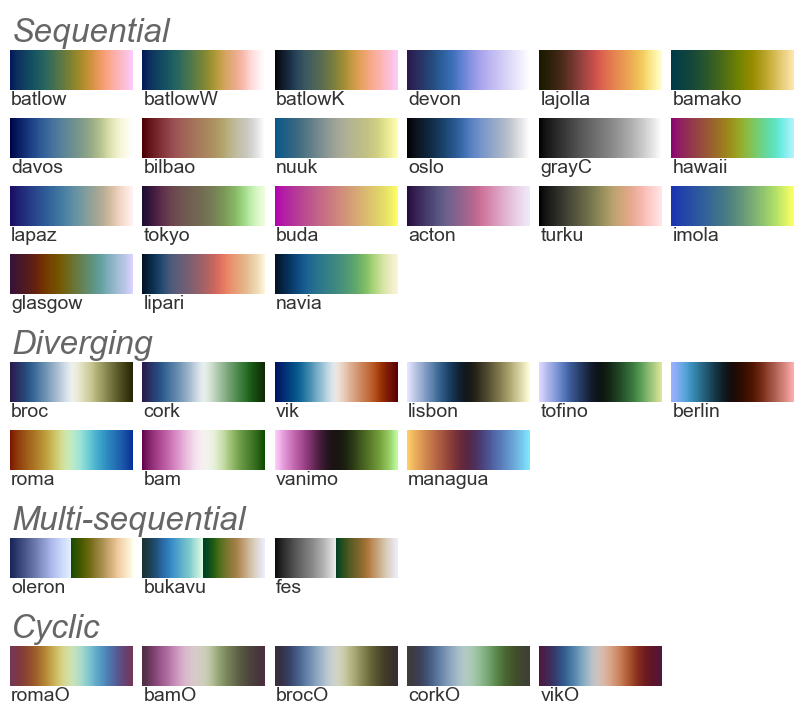

In [3]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

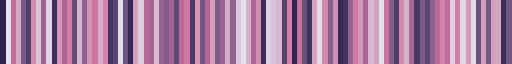

In [4]:
cmcrameri.cm.actonS

Set parameters

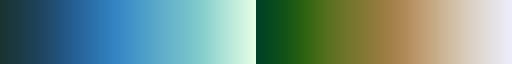

In [5]:
cmcrameri.cm.bukavu

In [6]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2016)]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# classifiacation_palette = ['#00429d', '#93003a','#ffffe0']
classifiacation_palette = cmcrameri.cm.actonS.colors[[i for i in range(10) if i != 1],:]
temperature_palette = ["#0d0d0f",'#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
default_colormap=cmcrameri.cm.acton

Load data

## Load data

In [7]:
cpp_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/2010/05/13/CPPin20100513073000405SVMSG01MD.nc")
ctx_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/2010/05/13/CTXin20100513073000405SVMSG01MD.nc")
aggregated_sp  = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/sp/2010/05/13/Agg_03_20100513073000.nc")
aux_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)
filtered_data_sp=[]
for t in range(6,37,6):
    filtered_data_sp.append(xr.load_dataset(f"/wolke_scratch/dnikolo/CLAAS_Data/Filtered_Data/sp/2010/05/13/Agg_03_T_{t:02}_{(t-6):02}_20100513073000.nc"))

In [8]:
cpp_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2010/05/13/CPPin20100513073000405SVMSG01MD.nc")
ctx_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2010/05/13/CTXin20100513073000405SVMSG01MD.nc")
aggregated_np  = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/np/2010/05/13/Agg_03_20100513073000.nc")
aux_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)
filtered_data_np=[]
for t in range(6,37,6):
    filtered_data_np.append(xr.load_dataset(f"/wolke_scratch/dnikolo/CLAAS_Data/Filtered_Data/np/2010/05/13/Agg_03_T_{t:02}_{(t-6):02}_20100513073000.nc"))


In [9]:
aux_data_full_globe = xr.load_dataset("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/aux_data_full_globe.nc",decode_times=False)

# Ploting

In [10]:
# mpl.use('PDF')
plt.close('all')

## Def plotting functions

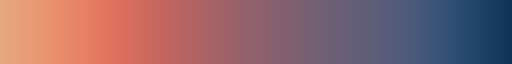

In [11]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'mycmap', 
    ['#ca0020', '#0571b0']
)

# cph_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'mycmap', 
#     [
#     cmcrameri.cm.managua.colors[0],
#     cmcrameri.cm.managua.colors[-1]]
# )
# cph_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'mycmap', 
#     ['#ca0020', '#0571b0']
# )
# cph_cmap = mpl.colors.LinearSegmentedColormap.from_list("managua_middle", cmcrameri.cm.managua.colors[int(0.15*255):int(0.85*255)])
cph_cmap = mpl.colors.LinearSegmentedColormap.from_list("lipari_left", cmcrameri.cm.lipari.colors[int(0.1*255):int(0.8*255)][::-1])
# cph_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'mycmap', 
#     cmcrameri.cm.lipariS.colors[[2,4]]
# )
#['#e41a1c', '#377eb8']
# Create a normalization to map 1 -> #ca0020, 2 -> #0571b0
ctt_cmap="plasma"
cph_norm = mcolors.Normalize(vmin=1, vmax=2)
ctt_vmin=200
ctt_vmax=300

# Select a continuous colormap (e.g., 'viridis')
cmap_cont_filter = cmcrameri.cm.lipari

# Number of discrete levels
levels = 6

# Sample colors evenly from the continuous map
colors_filtered_classes = cmap_cont_filter(np.linspace(0, 0.7, levels))
colors_filtered_classes = colors_filtered_classes[::-1]
# Create a new discrete colormap
cmap_filtered_classes = ListedColormap(colors_filtered_classes, name='liari_filtered_classes')
cmap_filtered_classes
cph_cmap

In [12]:
def put_on_globe(arr_np,arr_sp):
    assert arr_np.shape==arr_sp.shape,"Two arrays of unequal size"
    assert len(arr_np.shape)==2,"The input arrays are not 2D"
    arr_shape =arr_np.shape
    full_size=3712
    start_idx_y=51
    end_idx_y = 3660
    if arr_shape[1]<2000:
        full_size//=3
        start_idx_y//=3
        end_idx_y //=3
    arr_shape=arr_np.shape
    full_image = np.full((full_size,full_size),np.nan)
    start_idx_x=int((full_image.shape[1]-arr_shape[1])/2)
    end_idx_x=start_idx_x+arr_shape[1]
    full_image[start_idx_y:start_idx_y+arr_shape[0],start_idx_x:end_idx_x]=arr_np
    full_image[end_idx_y-arr_shape[0]:end_idx_y,start_idx_x:end_idx_x]=arr_sp
    return full_image




In [13]:
def first_and_last_true2d(arr):
    arr_copy = arr.copy()
    m, n = arr.shape

    # mask of positives
    mask = arr > 0

    # --- first positive in each row ---
    # where mask=True take the column index, else n (past-the-end)
    idxs = np.where(mask, np.arange(n), n)
    first_pos = idxs.min(axis=1)        # min gives first True (or n)

    # --- last positive in each row ---
    # where mask=True take the column index, else -1 (before-the-start)
    idxs_back = np.where(mask, np.arange(n), -1)
    last_pos = idxs_back.max(axis=1)    # max gives last True (or -1)

    # which rows actually had any positives?
    has_pos = mask.any(axis=1)

    rows = np.nonzero(has_pos)[0]       # array of row-indices with positives

    # set first & last to -1
    arr_copy[rows, first_pos[has_pos]] = -1
    arr_copy[rows, last_pos[has_pos]]   = -1

    # count rows with no positives
    count = (~mask.any(axis=1)).sum()
    print(count)
    return arr_copy

def plot_minus1_contour(arr,ax, linewidth=1 ):
    """
    Plot the -1 contour of a 2D array (everything else can be NaN)
    as a single gray line.
    
    Parameters
    ----------
    arr : 2D ndarray
        Your array, with -1 marking the contour and everything else NaN.
    figsize : tuple of int, optional
        Figure size in inches.
    linewidth : float, optional
        Width of the contour line.
    """
    # Boolean mask: True where arr == -1
    mask = (arr == -1).astype(int)

    ax.contour(
        mask,
        levels=[0.5],
        colors='gray',
        linewidths=linewidth,
        antialiased=True,
        alpha=0.2
    )
boundary_array = first_and_last_true2d(aux_data_full_globe.lsm.values[0])
def plot_background_map(ax):
    plot_minus1_contour(boundary_array,ax)
    ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays",interpolation='none')
    

102


In [14]:
# Aggregate boundary array
pre_agg_boundary = boundary_array.copy()

# figure out how much padding is needed on each axis
pad_h = (3 - pre_agg_boundary.shape[0] % 3) % 3
pad_w = (3 - pre_agg_boundary.shape[1] % 3) % 3

# pad with something smaller than your real data so it never wins the max
pad_val = np.nan
arr_padded = np.pad(pre_agg_boundary,
                    ((0, pad_h), (0, pad_w)),
                    mode='constant',
                    constant_values=pad_val)

# compute the new aggregated shape
H, W = arr_padded.shape
new_h = H // 3   # number of 3‐row blocks
new_w = W // 3   # number of 3‐col blocks

# now reshape with explicit block counts, then max‐pool
boundary_array_agg = (np.nanmax(arr_padded.reshape(new_h, 3, new_w, 3),axis=(1, 3))).T

print(boundary_array_agg.shape)   # -> (new_h, new_w)

(1238, 1238)


/tmp/ipykernel_29404/2072548970.py:21: RuntimeWarning: All-NaN slice encountered
  boundary_array_agg = (np.nanmax(arr_padded.reshape(new_h, 3, new_w, 3),axis=(1, 3))).T


In [15]:
def put_on_globe_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp):
    arr_shape = cph_np.shape
    full_size=3712
    start_idx_y=51
    end_idx_y = 3660
    if arr_shape[1]<2000:
        full_size//=3
        start_idx_y//=3
        end_idx_y //=3
    left_half = np.full((full_size,full_size),np.nan)
    right_half = np.full((full_size,full_size),np.nan)
    arr_shape = cph_np.shape
    start_idx_x=(right_half.shape[1]-arr_shape[1])//2
    end_idx_x=start_idx_x+arr_shape[1]
    mid_idx_x=(start_idx_x+end_idx_x)//2
    left_half[start_idx_y:start_idx_y+arr_shape[0],start_idx_x:mid_idx_x]=cph_np[:,:mid_idx_x-start_idx_x]
    left_half[end_idx_y-arr_shape[0]:end_idx_y,start_idx_x:mid_idx_x]=cph_sp[:,:mid_idx_x-start_idx_x]
    right_half[start_idx_y:start_idx_y+arr_shape[0],mid_idx_x:end_idx_x]=ctt_np[:,-(end_idx_x-mid_idx_x):]
    right_half[end_idx_y-arr_shape[0]:end_idx_y,mid_idx_x:end_idx_x]=ctt_sp[:,-(end_idx_x-mid_idx_x):]
    return left_half,right_half , (start_idx_x,mid_idx_x,end_idx_x),(start_idx_y,end_idx_y)

def add_ctt_cph_cbars_vertical(im_left,im_right,fig):
    cbar_left = fig.colorbar(im_left, shrink=0.5 ,aspect=10,location='bottom')
    # Set two ticks at 1 and 2, with labels
    cbar_left.set_ticks([1, 2])
    cbar_left.set_ticklabels(['Liquid', 'Ice'],fontsize=6,fontweight='bold')

    tick_labels = cbar_left.ax.yaxis.get_ticklabels()
    # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_verticalalignment('bottom')
    # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_verticalalignment('top')
    cbar_right = fig.colorbar(im_right, shrink=0.5 ,aspect=10,location='top')
    # Force the colorbar range to [1, 2] with no extra margins
    cbar_right.ax.set_ylim(ctt_vmin, ctt_vmax)

    # Set two ticks at 1 and 2, with labels
    cbar_right.set_ticks([ctt_vmin, ctt_vmax])
    cbar_right.set_ticklabels([f'{ctt_vmin:d}K', f'{ctt_vmax:d}K'],fontsize=6,fontweight='bold')
    # Adjust vertical alignment of the two tick labels
    tick_labels = cbar_right.ax.yaxis.get_ticklabels()
    # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_verticalalignment('bottom')
    # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_verticalalignment('top')

def add_axins(left_side,right_side,ax):
    # first inset
    # xlim_left=[1720,1747]
    # ylim_left=[272,287]
    # xlim_right=[2070,2097]
    # ylim_right=[3272,3287]
    
    # New locations (13, 17, 464, 490)
    # ylim_left=[20, 10]
    # xlim_left=[474, 490]
    ylim_left=[35, 28]
    xlim_left=[567, 586]
    ylim_right=[35, 28]
    xlim_right=[567, 586]
    for i in range(len(xlim_right)):
            xlim_left[i]*=3
            ylim_left[i]*=3
            xlim_right[i]*=3
            ylim_right[i]*=3
    if left_side.shape[0]<3000:
        for i in range(len(xlim_right)):
            xlim_left[i]//=3
            ylim_left[i]//=3
            xlim_right[i]//=3
            ylim_right[i]//=3
    axins_left = ax.inset_axes([0.05, 0.3, 0.4, 0.4], xlim=xlim_left, ylim=ylim_left)
    axins_left.imshow(left_side, cmap=cph_cmap, norm=cph_norm,interpolation='none')
    print(f"Left side shape: {left_side.shape}")
    mark_inset(ax, axins_left, loc1=1, loc2=2, fc="none", ec="black", lw=1)
    axins_left.tick_params(
        axis='both',        # both axes
        which='both',       # both major and minor ticks
        left=False,         # no ticks on the left
        right=False,        # no ticks on the right
        bottom=False,       # no ticks on the bottom
        top=False,          # no ticks on the top
        labelleft=False,    # no labels on the left
        labelbottom=False,  # no labels on the bottom
        labelright=False,   # etc.
        labeltop=False
    )
    # second inset
    axins_right = ax.inset_axes([0.55, 0.3, 0.4, 0.4], xlim=xlim_right, ylim=ylim_right)
    axins_right.imshow(right_side, cmap=ctt_cmap, vmin = ctt_vmin, vmax=ctt_vmax,interpolation='none')
    mark_inset(ax, axins_right, loc1=1, loc2=2, fc="none", ec="black", lw=1,clip_box=None)
    axins_right.tick_params(
        axis='both',        # both axes
        which='both',       # both major and minor ticks
        left=False,         # no ticks on the left
        right=False,        # no ticks on the right
        bottom=False,       # no ticks on the bottom
        top=False,          # no ticks on the top
        labelleft=False,    # no labels on the left
        labelbottom=False,  # no labels on the bottom
        labelright=False,   # etc.
        labeltop=False
    )


def plot_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp,ax):
    cph_np[cph_np<1]=np.nan 
    cph_sp[cph_sp<1]=np.nan
    ctt_np[ctt_np<1]=np.nan 
    ctt_sp[ctt_sp<1]=np.nan
    left_side , right_side, x_tuple,y_tuple = put_on_globe_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp)
    if cph_np.shape[1]<1500:
        im_left = ax.imshow(left_side, cmap = cph_cmap ,interpolation='none')
    else:
        im_left = ax.imshow(left_side, cmap = cph_cmap , norm = cph_norm,interpolation='none')
    im_right =  ax.imshow(right_side,cmap=ctt_cmap, vmax=ctt_vmax, vmin=ctt_vmin,interpolation='none')
    
    ax.vlines(x_tuple[1],y_tuple[0],y_tuple[1],colors='black',alpha=0.4,linestyles="--",linewidths=1)
    ax.hlines([y_tuple[0]+cph_np.shape[0],y_tuple[1]-cph_np.shape[0]],x_tuple[0],x_tuple[2],colors='black',alpha=0.2,linewidths=1)
    add_axins(left_side,put_on_globe_filtered(ctt_np,ctt_sp)[0],ax)
    
    return im_left, im_right
  

In [16]:
def add_ctt_cph_cbars_horizontal(im_left,im_right,fig,cax_upper,cax_lower,agg=False):
    # cbar_left = fig.colorbar(im_left, shrink=0.5 ,aspect=10,location='bottom',anchor=(0.2,1.0))
    if not agg:
        colors =  [cph_cmap(0.0), cph_cmap(1.0)]
        cmap = ListedColormap(colors)
        bounds = [0, 0.5, 1]
        norm = BoundaryNorm(bounds, cmap.N)
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        # Draw the colorbar with two equal segments and no ticks
        cbar_left = fig.colorbar(sm, cax=cax_lower, location="bottom", boundaries=bounds)
        # cbar_left.ax.xaxis.set_visible(False)
        # cbar_left = fig.colorbar(im_left, cax=cax_lower,location='bottom')
        # cbar_left.set_ticks([0.25, 0.75])
        cbar_left.set_ticks([0, 1])
    else:
        cbar_left = fig.colorbar(im_left, cax=cax_lower,location='bottom')
        # Set two ticks at 1 and 2, with labels
        cbar_left.set_ticks([1, 2])
    cbar_left.set_ticklabels(['Liquid', 'Ice'],fontsize=5)
    cbar_left.set_label('Cloud top phase',fontsize=6)
        
    # cbar_left.set_ticks([1, 2])
    tick_labels = cbar_left.ax.xaxis.get_ticklabels()
    # # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_horizontalalignment('left')
    # # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_horizontalalignment('right')
    cbar_right = fig.colorbar(im_right, cax=cax_upper,location='bottom',aspect=20)
    # Force the colorbar range to [1, 2] with no extra margins
    cbar_right.ax.set_xlim(ctt_vmin, ctt_vmax)

    # Set two ticks at 1 and 2, with labels
    cbar_right.set_ticks([ctt_vmin, ctt_vmax])
    cbar_right.set_ticklabels([f'{ctt_vmin:d}K', f'{ctt_vmax:d}K'],fontsize=5)
    cbar_right.set_label('Cloud top\ntemperature',fontsize=6)
    # Adjust vertical alignment of the two tick labels
    tick_labels = cbar_right.ax.xaxis.get_ticklabels()
    tick_labels[0].set_horizontalalignment('left')
    # # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_horizontalalignment('right')

In [17]:
import matplotlib.legend_handler as handler
import matplotlib.patches as mpatches
from matplotlib.text import Text

import matplotlib.patches as mpatches
from matplotlib.text import Text

class HandlerPatchBelow(handler.HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # coloured patch as before
        patch = mpatches.Rectangle(
            (xdescent, ydescent + fontsize*0.3),
            width, height*0.6,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth(),
            transform=trans
        )

        # rotated label below the patch
        txt = Text(
            xdescent + width/2,
            ydescent,
            orig_handle.get_label(),
            transform=trans,
            ha='center', va='top',
            fontsize=fontsize,
            rotation=45,                 # ← rotate 45°
            rotation_mode='anchor'       # ← keep the anchor point fixed
        )
        return [patch, txt]


def filtered_cb(ax,patches):
    # 1) hide the axis so it collapses to [0,1]×[0,1]
    ax.axis('off')

    # # 2) place the legend *inside* that box
    # ax.legend(
    #     handles=patches,
    #     loc='lower center',
    #     ncol=len(patches),
    #     bbox_to_anchor=(0, 0, 1, 1),     # (x0, y0, width, height) in ax‐coords
    #     bbox_transform=ax.transAxes,     # interpret bbox in axis coords
    #     mode='expand',                   # stretch the columns to fill the width
    #     borderaxespad=0,                 # no padding around the bbox
    #     handletextpad=0.5,               # small space between patch & label
    #     columnspacing=1                  # spacing between columns
        
    # )
    
    ax.legend(
        handles=patches,
        labels=[''] * len(patches),       # ← suppress the default side‐labels
        loc='lower center',
        ncol=len(patches),
        bbox_to_anchor=(0, 0, 1, 1),
        bbox_transform=ax.transAxes,
        mode='expand',
        handler_map={mpatches.Patch: HandlerPatchBelow()},
        borderaxespad=0,
        columnspacing=1,
        labelspacing=0.5,
        fontsize=6
    )

    # ax.legend(handles=patches, loc='lower center', ncol = len(patches))

def put_on_globe_filtered(arr_np,arr_sp):
    assert arr_np.shape==arr_sp.shape,"Two arrays of unequal size"
    assert len(arr_np.shape)==2,"The input arrays are not 2D"
    arr_shape =arr_np.shape
    full_size=3712
    start_idx_y=51
    end_idx_y = 3660
    if arr_shape[1]<2000:
        full_size//=3
        start_idx_y//=3
        end_idx_y //=3
    arr_shape=arr_np.shape
    full_image = np.full((full_size,full_size),np.nan)
    start_idx_x=int((full_image.shape[1]-arr_shape[1])/2)
    end_idx_x=start_idx_x+arr_shape[1]
    full_image[start_idx_y:start_idx_y+arr_shape[0],start_idx_x:end_idx_x]=arr_np
    full_image[end_idx_y-arr_shape[0]:end_idx_y,start_idx_x:end_idx_x]=arr_sp
    return full_image , (start_idx_x,end_idx_x),(start_idx_y,end_idx_y)

def plot_filtered(filtered_data_np,filtered_data_sp,ax,colors_filtered_classes):
    labels = [f"{(i+6):d} to {(i):d}" for i in range(-6,-37,-6)]  # or whatever labels you want

    # build proxy patches for the legend
    patches = []
    im_list=[]
    count=0
    for color, label, data_np,data_sp in zip(colors_filtered_classes, labels, filtered_data_np, filtered_data_sp):
        if count != -1:
            # binarise your data
            temp_np = data_np["cph_filtered"].values[0].copy()
            temp_sp = data_sp["cph_filtered"].values[0].copy()
            temp_np[temp_np <= 0] = np.nan
            temp_np[~np.isnan(temp_np)] = 1
            temp_sp[temp_sp <= 0] = np.nan
            temp_sp[~np.isnan(temp_sp)] = 1

            # create a 1-entry colormap
            cmap_temp = ListedColormap([color])
            full_image , x_tuple , y_tuple = put_on_globe_filtered(temp_np,temp_sp)
            # plot it
            im_list.append(ax.imshow(full_image, cmap=cmap_temp, interpolation='none'))
            
            # create a patch with the same color for the legend
            patch = mpatches.Patch(color=color,label=label)
            patches.append(patch)
        count+=1
    fig_shape = filtered_data_np[0]["cph_filtered"].shape[1:]
    # print(fig_shape,y_tuple)
    ax.hlines([y_tuple[0]+fig_shape[0],y_tuple[1]-fig_shape[0]],x_tuple[0],x_tuple[1],colors='black',alpha=0.2,linewidths=1)
    # ax.text(x=x_tuple[1], y=y_tuple[0]+fig_shape[0] ,s="30°",fontsize=4,va="top")
    # add the legend with your patches
    return im_list, patches

def add_axins_filtered(filtered_data_np,filtered_data_sp,ax):
    # first inset
    # xlim_left=[1720,1747]
    # ylim_left=[272,287]
    # xlim_right=[2070,2097]
    # ylim_right=[3272,3287]
    # xlim_left=[1520,1547]
    # ylim_left=[272,287]
    # xlim_right=[2070,2097]
    # ylim_right=[3272,3287]
    # New locations (33, 586, 30, 569)
    # ylim_left=[20, 10]
    # xlim_left=[474, 490]
    ylim_left=[35, 28]
    xlim_left=[567, 586]
    ylim_right=[35, 28]
    xlim_right=[567, 586]
    for i in range(len(xlim_right)):
            xlim_left[i]*=3
            ylim_left[i]*=3
            xlim_right[i]*=3
            ylim_right[i]*=3
    if filtered_data_np[0]["cph_filtered"].shape[1]<3000:
        for i in range(len(xlim_right)):
            xlim_left[i]//=3
            ylim_left[i]//=3
            xlim_right[i]//=3
            ylim_right[i]//=3
    axins_left = ax.inset_axes([0.05, 0.3, 0.4, 0.4], xlim=xlim_left, ylim=ylim_left)
    # axins_left.imshow(left_side, cmap=cph_cmap, norm=cph_norm,interpolation='none')
    plot_filtered(filtered_data_np,filtered_data_sp,axins_left,colors_filtered_classes)
    mark_inset(ax, axins_left, loc1=1, loc2=2, fc="none", ec="black", lw=1)
    axins_left.tick_params(
        axis='both',        # both axes
        which='both',       # both major and minor ticks
        left=False,         # no ticks on the left
        right=False,        # no ticks on the right
        bottom=False,       # no ticks on the bottom
        top=False,          # no ticks on the top
        labelleft=False,    # no labels on the left
        labelbottom=False,  # no labels on the bottom
        labelright=False,   # etc.
        labeltop=False
    )
    # second inset
    # axins_right = ax.inset_axes([0.55, 0.3, 0.4, 0.4], xlim=xlim_right, ylim=ylim_right)
    # # axins_right.imshow(right_side, cmap=ctt_cmap, vmin = ctt_vmin, vmax=ctt_vmax,interpolation='none')
    # plot_filtered(filtered_data_np,filtered_data_sp,axins_right,colors_filtered_classes)
    # mark_inset(ax, axins_right, loc1=1, loc2=2, fc="none", ec="black", lw=1,clip_box=None)
    # axins_right.tick_params(
    #     axis='both',        # both axes
    #     which='both',       # both major and minor ticks
    #     left=False,         # no ticks on the left
    #     right=False,        # no ticks on the right
    #     bottom=False,       # no ticks on the bottom
    #     top=False,          # no ticks on the top
    #     labelleft=False,    # no labels on the left
    #     labelbottom=False,  # no labels on the bottom
    #     labelright=False,   # etc.
    #     labeltop=False
    # )

## Actual plot

In [42]:
plt.close('all')
plt.clf()

<Figure size 640x480 with 0 Axes>

In [43]:
cph_np= cpp_data_np["cph"].values[0].copy()
cph_sp=cpp_data_sp["cph"].values[0].copy()
ctt_np= ctx_data_np["ctt"].values[0].copy()
ctt_sp=ctx_data_sp["ctt"].values[0].copy()

Left side shape: (3712, 3712)


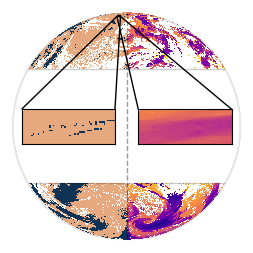

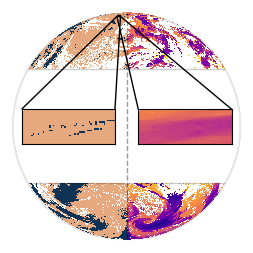

In [44]:
fig = plt.figure(figsize=(7.08, 9.322), constrained_layout=True)
gs = gridspec.GridSpec(10, 6,height_ratios=[0.1,1,0.05,0.1,1,0.05,0.1,1,0.05,0.5],width_ratios=[1,1,1,1,1,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[1, :2])
# ax_colorbar_upper=fig.add_subplot(gs[2, 1])
# ax_colorbar_lower=fig.add_subplot(gs[2, 0])
ax1.axis('off')
im_left, im_right =plot_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp,ax1)
plot_minus1_contour(boundary_array,ax1)
# add_ctt_cph_cbars_horizontal(im_left,im_right,fig,ax_colorbar_upper,ax_colorbar_lower)
# plot_background_map(ax)

# plt.tight_layout()
fig

In [45]:
# remove_axis(ax2)
# remove_axis(ax2_2)
# remove_axis(ax2_3)
cph_agg_np= aggregated_np["cph_resampled"].values[0].copy()
cph_agg_sp=aggregated_sp["cph_resampled"].values[0].copy()
ctt_agg_np= aggregated_np["ctt_resampled"].values[0].copy()
ctt_agg_sp=aggregated_sp["ctt_resampled"].values[0].copy()
ax2 = fig.add_subplot(gs[1, 2:4])
ax2_2=fig.add_subplot(gs[2, 0:2])
ax2_3=fig.add_subplot(gs[2, 2:4])
ax2.axis('off')
im_left, im_right = plot_cph_ctt(cph_agg_np,cph_agg_sp,ctt_agg_np,ctt_agg_sp,ax2)
add_ctt_cph_cbars_horizontal(im_left,im_right,fig,ax2_3,ax2_2,agg=True)
plot_minus1_contour(boundary_array_agg,ax2)
# plot_minus1_contour(boundary_array,ax2)

fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.png",
    format="png",
    dpi=300
    # no bbox_inches argument at all
)


Left side shape: (1237, 1237)


In [46]:
def remove_axis(ax):
    # remove all artists
    for artist in list(ax.artists):
        artist.remove()

    # remove all lines
    for line in list(ax.lines):
        line.remove()

In [47]:
# fig, ax = plt.subplots()
# ax.colorbar(position="bottom")

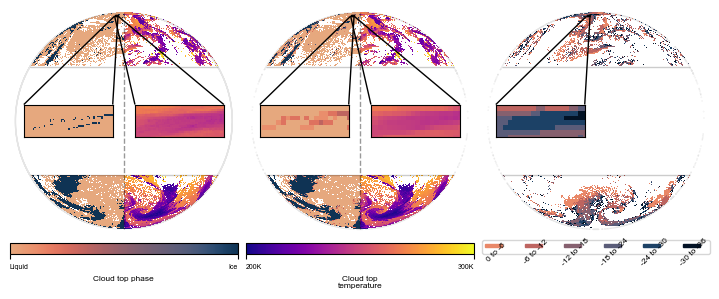

In [48]:
# 
# ax3.relim()
# ax4.relim()
# remove_axis(ax3)
# remove_axis(ax4)
# fig = plt.figure(figsize=(5.501, 7.701), constrained_layout=True)
# gs = gridspec.GridSpec(6, 6,height_ratios=[0.1,1,0.1,1, 1,1],width_ratios=[1,1,1,1,1,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.

ax3 = fig.add_subplot(gs[1, 4:])
ax4 = fig.add_subplot(gs[2, 4:])
ax3.axis('off')
im_list, patches = plot_filtered(filtered_data_np,filtered_data_sp,ax3,colors_filtered_classes)
add_axins_filtered(filtered_data_np,filtered_data_sp,ax3)
plot_minus1_contour(boundary_array_agg,ax3)
filtered_cb(ax4,patches)
# ax4.relim()

# fig.savefig("test.png",dpi=300)
# fig.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.pdf",
#     format="pdf",
#     dpi=300
#     # no bbox_inches argument at all
# )
fig


## Saving plot

In [49]:
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.eps",
    format="eps",
    dpi=300
    # no bbox_inches argument at all
)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.png",
    format="png",
    dpi=300
    # no bbox_inches argument at all
)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [ ]:
# from PIL import Image as im
# image = im.frombytes('RGB', fig.canvas.get_width_height(), fig.canvas.buffer_rgba())
# image.save('/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.bmp')

In [39]:
# fig.canvas._print_pil('/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.bmp', fmt="BMP", pil_kwargs={})

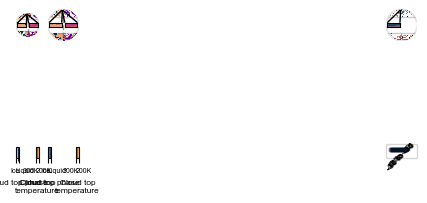

In [ ]:
# fig

Tracking

In [41]:
# ax3_0=fig.add_subplot(gs[3, :3])


# Old figure

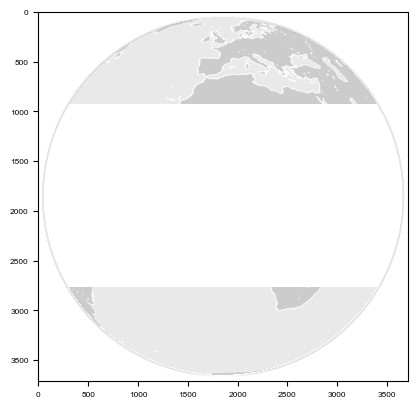

In [27]:
fig, ax = plt.subplots()
ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays")
plot_minus1_contour(boundary_array,ax, linewidth=1 )

In [ ]:
# Create old figure.
fig = plt.figure(figsize=(3,5))

# Create an axes that fills the entire figure: [left, bottom, width, height]
ax = fig.add_axes([0, 0, 1, 1])
# ax.imshow(aux_data_np.lsm[0,:,:], alpha=0.2,cmap="Greys")
ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays")
plot_minus1_contour(boundary_array,ax, linewidth=1 )
# Display the image.
cph_np= cpp_data_np["cph"].values[0].copy()
cph_sp=cpp_data_sp["cph"].values[0].copy()
cph_np[cph_np<1]=np.nan 
cph_sp[cph_sp<1]=np.nan

im = ax.imshow(put_on_globe(cph_np,cph_sp), cmap = custom_cmap , norm = norm)

# Remove all borders and ticks.
ax.axis('off')
# Create a shorter colorbar
cbar = fig.colorbar(im, shrink=0.3 ,aspect=7,location='left')

# Force the colorbar range to [1, 2] with no extra margins
cbar.ax.set_ylim(1, 2)

# Set two ticks at 1 and 2, with labels
cbar.set_ticks([1, 2])
cbar.set_ticklabels(['Liquid', 'Ice'],fontsize=6,fontweight='bold')

# Adjust vertical alignment of the two tick labels
tick_labels = cbar.ax.yaxis.get_ticklabels()
# The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
tick_labels[0].set_verticalalignment('bottom')
# The second label (index 1) is at value=2 => align its *top* with the colorbar top
tick_labels[1].set_verticalalignment('top')

# first inset
axins_left = ax.inset_axes([0.6, 0.3, 0.4, 0.4], xlim=(1720,1747), ylim=(272,287))
axins_left.imshow(put_on_globe(cph_np,cph_sp), cmap=custom_cmap, norm=norm)
mark_inset(ax, axins_left, loc1=1, loc2=2, fc="none", ec="black", lw=1)
axins_left.tick_params(
    axis='both',        # both axes
    which='both',       # both major and minor ticks
    left=False,         # no ticks on the left
    right=False,        # no ticks on the right
    bottom=False,       # no ticks on the bottom
    top=False,          # no ticks on the top
    labelleft=False,    # no labels on the left
    labelbottom=False,  # no labels on the bottom
    labelright=False,   # etc.
    labeltop=False
)
# second inset
axins_right = ax.inset_axes([0.1, 0.3, 0.4, 0.4], xlim=(1770,1797), ylim=(3272,3287))
axins_right.imshow(put_on_globe(cph_np,cph_sp), cmap=cph_cmap, norm=norm)
mark_inset(ax, axins_right, loc1=3, loc2=4, fc="none", ec="black", lw=1,clip_box=None)
axins_right.tick_params(
    axis='both',        # both axes
    which='both',       # both major and minor ticks
    left=False,         # no ticks on the left
    right=False,        # no ticks on the right
    bottom=False,       # no ticks on the bottom
    top=False,          # no ticks on the top
    labelleft=False,    # no labels on the left
    labelbottom=False,  # no labels on the bottom
    labelright=False,   # etc.
    labeltop=False
)


KeyboardInterrupt: 